# ARIM-Academy：　基礎編　RDKitの基本操作

## 前提知識・動作環境・版とライセンス

**前提知識**：化学構造式・SMILES表記の基礎的な読み方（本編でも簡単に解説します）。統計学・機械学習の予備知識は不要です。

**動作環境**：
- Python 3.10以降
- `rdkit` 2023.x以降（`pip install rdkit`でインストールできる公式パッケージ。バージョンにより描画結果が若干異なる場合があります）
- Jupyter Notebook / JupyterLab、または Google Colab

**版とライセンス**：
- RDKit本体はBSD-3-Clauseライセンスで公開されているオープンソースソフトウェアです。
- 本編で使用するアスピリンの構造データ（`data/aspirin.mol`, `data/aspirin.sdf`）は [ChemSpider](https://www.chemspider.com/)（CSID: 2157）由来のデータを教材用に整形したものです。ファイル内の`<CSID>`タグから出典を確認できます。


## 本編の目標

RDKitにおける化学構造情報のファイル操作の基本となる

1. **ファイルの読み取り**
1. **分子構造の描画**
1. **ファイルへの保存**

の３つの操作について学びます。

**図1** 本編で学ぶ3つの操作の全体像

![図1 本編で学ぶ3つの操作の全体像](./img/image-1-2.png)

## 化学構造情報のフォーマット
<div style="border:1px solid #000; padding:10px;">
以下は、代表的な化学情報表現のフォーマットの定義と使い方をまとめたものです。化学情報を文字列として表現する**文字列型**と、分子を構成する原子の位置情報を座標として含む**座標型**との二系統に分類されます。  赤字のフォーマットは機械学習等の化学情報処理では比較的に多用される化学構造情報です。

**図2** 化学構造情報の代表的なフォーマット（文字列型・座標型）

![図2 化学構造情報の代表的なフォーマット](./img/image-1-1.png)

---

## RDKitライブラリについて

RDKitはPythonで使用されるオープンソースの化学情報処理のライブラリで、特に近年ではケモインフォマティクスにおける化学情報の取り扱いでは必ず用いられます。RDKitは分子の構造描画、特性の計算、データベースの操作のほか、インフォマティックスで必要となる記述子（ディスクリプタ）やフィンガープリントをサポートし、医薬品設計、材料科学などのマテリアル設計における機械学習モデルの研究開発において重要なツールとなっています。

このパートではRDKitの基本となる化学情報の読み込み、変換、出力について一連の操作方法を学んで行きます。

___

**RDKitの強み**  
RDKitは分子の構造から特性を計算するための多くの関数やアルゴリズムを実装しています。また、化学反応の予測や合成経路の設計など、さまざまな化学的なタスクをサポートしています。化学分野で一般的なChemDrawと比較すると、RDKitはプログラミングに基づいたアプローチを取っており、自動化や大規模なデータ処理に適していることが特徴です。

**RDKitの弱み**  
RDKitそのものは分子構造を画面上からインターラクティブに描くDraw機能は有してはいません。ChemDrawは直感的なユーザーインターフェースを通じて分子を作成し、編集するための強力な機能を提供しますが、そのようなことはRDKitでは行えません。

もう一つのRDKitを利用する場合の留意点としては、RDKitはChemDrawファイル（.cdxファイル）を直接的に読み込むことはできません。化合物情報の読み込みは、主にSMILES表記やMOLファイルなどのテキストベースの化学情報表現を処理するために設計されています。

___

## ChemDrawファイルをRDKitで使用するためには  
ChemDrawファイルをRDKitが読み込める形式に変換する必要があります。

* ChemDraw自体にはエクスポート機能を利用します。例えば、RDKitでサポートされているフォーマット（SDF、MOL、MOL2など）に変換します。
* オープンソースの**Open babel**を利用して.cdxファイルを変換することができます。

 ___

### 教材への接続
google colabにおけるオンラインの場合にこのラインを実行します。（<font color="red">Google colabに接続しない場合には不要</font>）

In [ ]:
!pip install rdkit
!git clone https://github.com/ARIM-ACADEMY-2026/Advanced_Tutorial_2_RDKit.git
%cd Advanced_Tutorial_2_RDKit

### ライブラリのインポート
RDkitでコンフォーマーサーチを行うためのpythonのライブラリをimport文でロードします。
化学情報として分子構造の読み込みに関する機能は、RDKitの`Chem`モジュールにツール群が含まれています。  
はじめに`Chem`モジュールをpythonの`import`機能でインポートします。

In [1]:
from rdkit import Chem

### 1.MOLファイルからの読み込み手順

このセクションでは、初心者にもわかりやすく、解熱鎮痛剤のアセチルサリチル酸（アスピリン）を例にして、MOL形式ファイルからデータを読み込む方法を紹介します。

MOL形式ファイルは、オープンな化学データベース（例：ChemSpider）や試薬メーカーなどから入手できます。具体的な例として、以下のChemSpiderのリンクからアスピリンのMOLファイルをダウンロードしてみましょう。
[ChemSpider - Aspirin MOLファイル](https://www.chemspider.com/Chemical-Structure.2157.html?rid=e668649a-f75f-4644-8419-29e064351376)

次に、ダウンロードしたaspirin.molとしてMOLファイルは、[data]という名前のフォルダに保存されていることを想定しています。これを前提に進めていきましょう。

In [2]:
#fileの相対パスを定義
file ='data/aspirin.mol'

#fileの読み込み
mol_aspirin = Chem.MolFromMolFile(file)

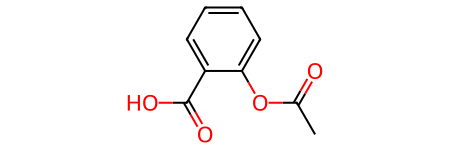

In [3]:
mol_aspirin

【解説】  **`Chem.MolFromMolFile()`** メソッド    
`Chem.MolFromMolFile`メソッドは、MOLファイルからRDKitの<font color="Red">**Molオブジェクト**</font>を作成するために使用されます。このMolオブジェクトは、分子の構造と属性を表現するための原子や結合の情報、立体情報、分子の特性などを保持しています。Molオブジェクトを使うことで、分子構造の解析や変換、また後述するフィンガープリントの分子の計算など、様々な分子情報処理の操作をメソッドを通じて行うことができます。

以下は、`Chem.MolFromMolFile`メソッドの基本的な使用例です。

~~~python
from rdkit import Chem
mol = Chem.MolFromMolFile('input.mol')
~~~

MOLファイルが不正確なフォーマットやエラーがある場合、メソッドは適切なエラーメッセージを返すか、`None`を返す場合があります。

### 1.2 SMILES形式から読み込みの場合
アスピリンの**SMILES(Simplified Molecular Input Line Entry System**による表記は"CC(OC1=C(C(=O)O)C=CC=C1)=O"となります。そのSMILESをRDKitに読み込ませる方法は、以下のように`MolFromSmiles`メソッドを用いて行います。

In [4]:
#アスピリンのSMILESを定義
smiles = "CC(OC1=C(C(=O)O)C=CC=C1)=O"

smiles_aspirin = Chem.MolFromSmiles(smiles)

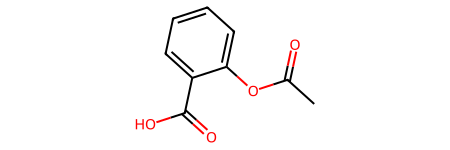

In [5]:
smiles_aspirin

【解説】 **`Chem.MolFromSmiles()`** メソッド  
`Chem.MolFromSmiles`メソッドは、SMILES（Simplified Molecular Input Line Entry System）形式の文字列を受け取り、それをRDKitのMolオブジェクトに変換します。

以下は、`Chem.MolFromSmiles`メソッドの基本的な使い方の例です。

```python
from rdkit import Chem

smiles = "CC(=O)Oc1ccccc1C(=O)O"
mol = Chem.MolFromSmiles(smiles)
```
与えられたSMILES文字列が無効な場合や解析できない場合にはメソッドは適切なエラーメッセージを返します。

### 1.3 Canonical SMILES（正規化された分子表現）
**Canonical SMILES（正規化された分子表現）**　とは化学物質の構造をテキストで一義的に表現するための正規化表現であり、異なる表現方法においても同じ構造に対して同じSMILESが生成される分子表現です。RDKitでは生成されるSMILESは**canonical SMILES**となります。  

例として、ピリジンの三つの異なるSMILES構造でRDKitに読み込ませた戻し値を見てみましょう。いずれも、"c1ccncc1"となっており、RDKitでは正規化表現となっていることが確認できます。

**図3** ピリジンの3通りのSMILES表記といずれも同一のcanonical SMILESに正規化されることを示す図

<img src="./img/pyridine.png" width="10%">

In [6]:
# ケース１
smiles1 ='C1=CC=CN=C1'

mol1 =Chem.MolFromSmiles(smiles1)
Chem.MolToSmiles(mol1)

'c1ccncc1'

In [7]:
# ケース2
smiles2 ='c1cccnc1'

mol2 = Chem.MolFromSmiles(smiles2)
Chem.MolToSmiles(mol2)

'c1ccncc1'

In [8]:
# ケース3
smiles3 ='n1ccccc1'

mol3 =Chem.MolFromSmiles(smiles3)
Chem.MolToSmiles(mol3)

'c1ccncc1'

### 1.4 SDFファイルからの読み込みの場合
SDF（Structure-Data File）はMOLフォーマットが複数含まれる形式となっています。ファイル拡張子としては.sdfとなっていることが多いでしょう。このファイルの場合`SDMolSupplier`メソッドを使って以下のように読み込みます。

In [9]:
#アスピリンのsdfファイルの相対パス
file ='data/aspirin.sdf'

sdf_aspirin = Chem.SDMolSupplier(file)
sdf_aspirin


SDF（Structure-Data File）の場合、取り込まれた情報は、メモリ内のオブジェクトのアドレスを返します。Pythonの専門用語で言うと、このオブジェクトは「イテレータ」と呼ばれます「イテレータ」はリストと同じく、要素を指定することで個別に呼び出すことができます。

【注意】`data/aspirin.sdf`には実は**2つの分子**が格納されています。1件目（インデックス0）はアスピリンそのものですが、2件目（インデックス1）は**アセチルサリチル酸エチルエステル**（アスピリンのカルボン酸をエチルエステル化した誘導体、`CCOC(=O)c1ccccc1OC(C)=O`）です。SDFファイルは複数の異なる化合物をまとめて格納できる形式であることを示す例として、あえて2種類の構造を収録しています。以降のセルで「2番目の要素」として扱われるのはこの誘導体である点に注意してください。


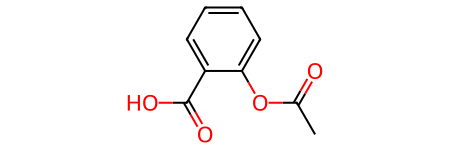

In [10]:
# sdfの最初の要素の呼び出し
sdf_aspirin[0]

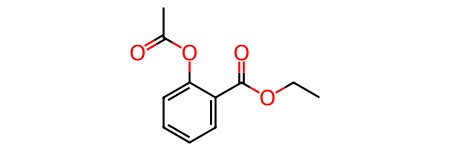

In [11]:
# sdfの2番目の要素の呼び出し
sdf_aspirin[1]

【解説】　**`SDMolSupplier`**　メソッド　　   
`SDMolSupplier`メソッド は、RDKitでSDF（Structure-Data File）形式のファイルを読み込みます。`SDMolSupplier`メソッドはイテレータとして機能し、ファイルから分子を順番に読み込むことができます。各分子の化学情報はMolオブジェクトとして提供されます。

以下は、`SDMolSupplier`メソッドの基本的な使い方を示す例です。

```python
from rdkit import Chem
supplier = Chem.SDMolSupplier('input.sdf')

for m in supplier:
    if m is not None:
        # 分子の処理
        print(Chem.MolToSmiles(m))
```

この例では、'input.sdf'というSDFファイルを`SDMolSupplier`で読み込みます。イテレータとして使われるため、`for`ループ内で分子を一つずつ取得することができます。

取得した分子は、`m`変数に格納されます。ただし、一部の分子は正しく読み込むことができない場合がある時には、適切なエラーメッセージを返します。

### 【Tips】sdfから連続的/逐次的に分子を呼び出す方法
イテレータを効果的に処理する最も一般的な方法は次の2通りの方法があります。
- forループ
- next関数

#### forループの場合
forループを使用することでデータの反復処理が効率的に行えます。

In [12]:
for x in sdf_aspirin:
    print(Chem.MolToSmiles(x))

CC(=O)Oc1ccccc1C(=O)O
CCOC(=O)c1ccccc1OC(C)=O


#### next関数の場合
イテレータに格納されている情報を読み出す別方法としては、逐次的に要素読み出す`next` 関数を使うことができます。`next` 関数数で初めて呼び出されるとイテレータは最初の要素を返し次に進みます。要素がなくなると `StopIteration` 例外が発生します。 

In [13]:
sdf2 = Chem.SDMolSupplier(file)

In [14]:
# 最初の化合物を呼び出します。
y = next(sdf2)
print(Chem.MolToSmiles(y))

CC(=O)Oc1ccccc1C(=O)O


In [15]:
# 2つめの化合物を呼び出します。
y = next(sdf2)
print(Chem.MolToSmiles(y))

CCOC(=O)c1ccccc1OC(C)=O


In [16]:
# 3回目ではすでに要素がないためStopIterationが発生します
y = next(sdf2)
print(Chem.MolToSmiles(y))

StopIteration: End of supplier hit

## 2. 分子構造の表示・可視化
読み込んだ分子の描画は`Chem`モジュールの配下にある`Draw`サブモジュールにツール群がまとめられいます。その`Draw`モジュールをimportします。なお、Jupyter Notebookでの描画はDrawモジュールに含まれている`IPythonConsole`をあらかじめインポートしておくとラインに表示されます。

In [17]:
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole

### 単一の分子を表示

ここでは例として無水フタル酸を化学情報として表示する例で説明を進めます。

In [18]:
#無水フタル酸のMolオブジェクト化

smiles = "O=C(OC(=O)c1cccc2)c12"
phthalic_anhydride = Chem.MolFromSmiles(smiles)

molオブジェクトの可視化は、下記のように`MolToImage`メソッドで表示されます。　　

【注意】なお、Jupyter Notebookでは、`Chem.Draw`モジュールの`IPythonConsole`をインポートさせておくことでRDKitモジュールが正しくインストールされている場合、`Mol`オブジェクトを直接表示することもできます。`Mol`オブジェクトの表示には、RDKitが組み込みのJupyter拡張機能を使用しているため、追加のコードは必要ありません。

In [19]:
img = Draw.MolToImage(phthalic_anhydride)

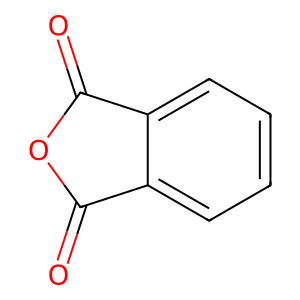

In [20]:
img

【解説】 **`MolToImage`** メソッド    
`MolToImage`メソッド は、RDKitの`Mol`オブジェクトを描画するために使用されます。以下は、`MolToImage`メソッドの基本的な使用例です。

```python
from rdkit import Chem
from rdkit.Chem import Draw

mol = Chem.MolFromSmiles('CCO')
img = Draw.MolToImage(mol)
img.show()
```

このコードでは、SMILES表記法で指定された分子を`MolFromSmiles`メソッドを使用して作成し、`MolToImage`メソッドから分子を描画します。なお、`MolToImage`メソッドはPIL（Python Imaging Library）の画像オブジェクトを返します。これより、`img.show`メソッドを使用することで画像が表示されます。

### 複数の分子をまとめて表示
次に複数分子の表示について説明します。MOLファイルやSMILESからmolオブジェクト化されていれば、それを`Draw.MolsToGridImage`メソッドで複数の分子を格子状に配置して描画することができます。以下では無水フタル酸とフタル酸ジメチルの二つの分子を表示する方法です。

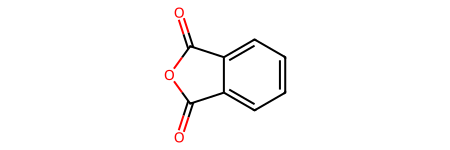

In [21]:
# 無水フタル酸
smiles = "O=C(OC(=O)c1cccc2)c12"
phthalic_anhydride = Chem.MolFromSmiles(smiles)
phthalic_anhydride

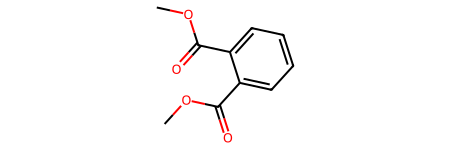

In [22]:
# フタル酸ジメチル
dimethyl_phthalate = Chem.MolFromSmiles('O=C(OC)c(c(ccc1)C(=O)OC)c1')
dimethyl_phthalate

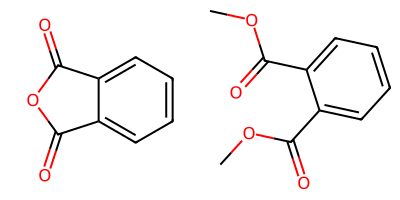

In [23]:
# 二つの分子をリスト配置
mol_list =[phthalic_anhydride,dimethyl_phthalate]

img2 = Draw.MolsToGridImage(mol_list, 
                            molsPerRow=2
                           )

img2

【解説】 **`MolsToGridImage`** メソッド 

`MolsToGridImage`メソッド は、複数のRDKitのMolオブジェクトをグリッド形式の画像として描画するために使用されます。以下は、`MolsToGridImage`メソッド の基本的な使用例です。

```python
from rdkit import Chem
from rdkit.Chem import Draw

mols = [Chem.MolFromSmiles('CCO'), Chem.MolFromSmiles('CNC'), Chem.MolFromSmiles('CCN')]
img = Draw.MolsToGridImage(mols, molsPerRow=3)
img.show()
```

`molsPerRow`パラメータは、1行あたりの分子の数を指定します。この例では、3つの分子が1行に表示されます。`MolsToGridImage`メソッドは、PIL（Python Imaging Library）の画像オブジェクトを返します。`img.show()`を使用することで、画像が表示されます。

`MolsToGridImage`メソッド には、さまざまなオプションがあります。たとえば、`legends`パラメータを使用して各分子のキャプションを指定したり、`highlightAtomLists`や`highlightBondLists`パラメータを使用して特定の原子や結合をハイライトしたりすることもできます。さらに、出力画像のサイズやスケーリング、カラースキームなどもカスタマイズすることができます。

### 複数の分子をまとめて表示２
続いては４つの分子についての表示例です。molsPerRow=3として横に３つの分子を配置します。

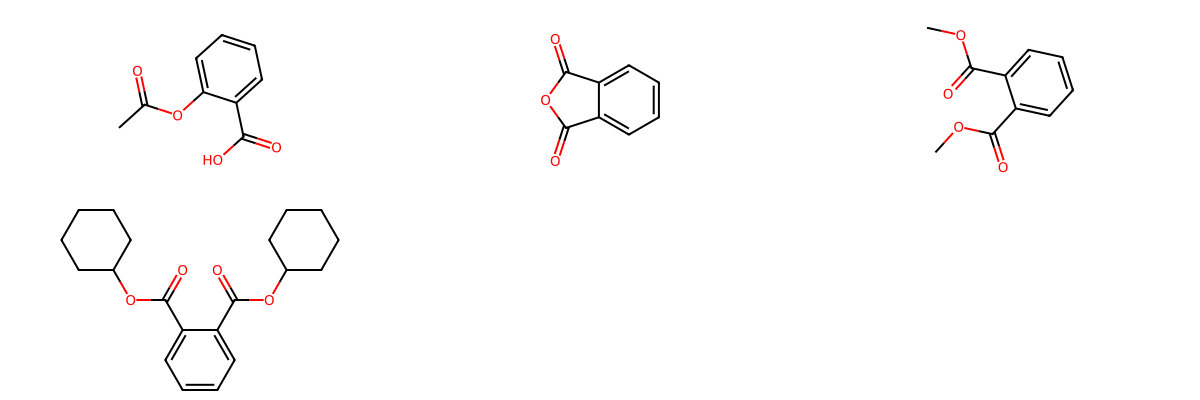

In [24]:
# ４つの分子をリスト配置
smiles = [
    'CC(=O)Oc1ccccc1C(=O)O',
    'O=C(OC(=O)c1cccc2)c12',
    'O=C(OC)c(c(ccc1)C(=O)OC)c1',
    'O=C(OC1CCCCC1)C2=C(C=CC=C2)C(OC3CCCCC3)=O'
]

mol_list = [Chem.MolFromSmiles(smi) for smi in smiles]

Draw.MolsToGridImage(mol_list, 
                     molsPerRow=3, 
                     subImgSize=(400, 200)
                    )

【解説】 **`subImgSize`** オプション

`subImgSize`は、`MolsToGridImage`メソッドのオプションの一つであり、それぞれの分子のサイズを指定するために使用されます。このオプションには、(width, height)という2つの値を持つタプルを指定します。

 width:  それぞれの分子の横幅をピクセル単位で指定  
 height: それぞれの分子の縦幅をピクセル単位で指定  

subImgSizeオプションにより、各分子のサイズを指定することで、描画される画像内での各分子の相対的な大きさを調整することができます。これにより、画像内の分子の配置や視覚的なバランスを調整することが可能です。

## 3. 分子情報の保存
RDKitを使用して構造情報などの分子情報を保存するには、基本としてMolオブジェクトからファイルに書き出す必要があります。  
RDKitは複数のファイル形式に対応しており、一般的な形式としてはMOL、SMILES、SDFフォーマットのほか、PDBや画像ファイルのjpegフォーマットなども出力が可能です。

【注意】以降のセルでは`./output/`フォルダに構造ファイルを保存します。フォルダが存在しない環境でも保存できるよう、あらかじめ`os.makedirs`でフォルダを作成しておきます（Google Colabで`git clone`した場合はすでに`output/`フォルダが存在しますが、`exist_ok=True`により問題なく実行できます）。


In [25]:
import os
os.makedirs('output', exist_ok=True)


### 3.1 MOLファイル形式で保存する場合：  
`MolToMolFile`モジュールを使います。SMILES表記法からMolオブジェクトを作成し、`MolToMolFile`メソッドを使用してMOLファイルに保存しています。第1引数に保存する`Mol`オブジェクトを指定し、第2引数に保存するファイル名（ファイルパス）を指定します。

In [26]:
smiles = "CC(OC1=C(C(=O)O)C=CC=C1)=O"
mol = Chem.MolFromSmiles(smiles)

#MOLファイルへの保存
save_file ='./output/aspirin_rdkit.mol'
Chem.MolToMolFile(mol, save_file)

### 3.2 SMILES形式で保存する場合：
SMILES表記は既に文字列であるため、Pythonの標準組み込み関数であるopen関数の書き込みモードから`write`関数を用いて操作が行えます。

In [27]:
smiles = "CC(OC1=C(C(=O)O)C=CC=C1)=O"

#MSMILESでの保存
save_file = './output/aspirin_rdkit.smi'
with open(save_file, 'w') as f:
    f.write(smiles)

### 3.3 SDFファイル形式で保存する場合：
SMILES表記法からMolオブジェクトを作成し、`SDWriter`メソッドよりSDFファイルに保存しています。標準ライブラリの組み込こまれている`write`メソッドを使用してMolオブジェクトを書き込み、`close`メソッドを使用してファイルを閉じます。

In [28]:
smiles = "CC(OC1=C(C(=O)O)C=CC=C1)=O"
mol = Chem.MolFromSmiles(smiles)

# SDFフォーマットでの保存
save_file = './output/aspirin_rdkit.sdf'
writer = Chem.SDWriter(save_file)
writer.write(mol)
writer.close()

### 3.4 PDBファイル形式で保存する場合：
PDBの場合は`Chem.PDBWriter`メソッドに変更するだけで、上記のSDFと変わりません。同じく、`write`メソッドを使用してMolオブジェクトを書き込み、`close`メソッドを使用してファイルを閉じます。

In [29]:
smiles = "CC(OC1=C(C(=O)O)C=CC=C1)=O"
mol = Chem.MolFromSmiles(smiles)

# PDBフォーマットでの保存
save_file = './output/aspirin_rdkit.pdb'
writer = Chem.PDBWriter(save_file)
writer.write(mol)
writer.close()

### 3.5 画像形式で保存する場合（JupyterNotebookのみ）：
png画像で保存する場合は、組み込み関数の`save`関数から次のように行えます。ただし、事前に`MolsToGridImage`メソッドで`returnPNG`オプションをFalseとしておくことが必要です。

In [30]:
molecules = [phthalic_anhydride, dimethyl_phthalate]

img = Draw.MolsToGridImage(molecules, 
                           molsPerRow=2,
                           returnPNG=False
                          )
# imageの保存
img.save('./output/molecules.jpg')

## RDKitの公式チュートリアル
より詳しい操作などはRDKitの公式チュートリアルで学習することができます。
https://github.com/rdkit/rdkit-tutorials

## まとめ

本編では、RDKitを用いた化学構造情報の基本操作として、以下の3点を扱いました。

1. **ファイルの読み取り**：MOLファイル（`Chem.MolFromMolFile`）、SMILES文字列（`Chem.MolFromSmiles`）、SDFファイル（`Chem.SDMolSupplier`）という3種類の代表的な入力形式からMolオブジェクトを作成する方法
2. **分子構造の描画**：`Draw.MolToImage`による単一分子の描画、`Draw.MolsToGridImage`による複数分子の一括描画
3. **ファイルへの保存**：MOL・SMILES・SDF・PDB・画像（PNG/JPEG）の各形式でのMolオブジェクトの書き出し

あわせて、SMILES表記には表記の揺れがあってもRDKitが同一のcanonical SMILESに正規化すること（図3）、SDFファイルには複数の異なる分子が格納できることも確認しました。

## 本ノートブックで扱っていないこと（今後の課題）

- 分子記述子・フィンガープリントの計算（Advanced編で扱います）
- 3次元座標の取り扱いやコンフォーマー生成
- 無効なSMILES・パースエラーが発生した場合の系統的なエラーハンドリング（本編では単一の正しい構造のみを例として使用しています）
- 機械学習モデルへの分子データの入力（本シリーズの他のノートブックで扱います）

## 演習問題

1. 任意の医薬品分子（例：イブプロフェン `CC(C)Cc1ccc(cc1)C(C)C(=O)O`）についてSMILESからMolオブジェクトを作成し、`Draw.MolToImage`で描画してみましょう。
2. 上記の分子を`MolToMolFile`でMOL形式として`./output/`に保存し、保存されたファイルをテキストエディタで開いてMOL形式の構造を確認してみましょう。
3. `data/aspirin.sdf`の2件目の分子（アセチルサリチル酸エチルエステル）についても、`MolToImage`で描画し、アスピリンとの構造上の違いを目視で確認してみましょう。
4. 3つ以上の分子を`Draw.MolsToGridImage`で1行2分子ずつ格子状に表示し、`legends`オプションで各分子に化合物名のキャプションを付けてみましょう。


In [31]:
# 演習問題1〜4はここに記述してください
